# **TikTok Project**
**Course 4 - Regression Analysis: Simplify complex data relationships**

In [ ]:
import numpy as np
import pandas as pd
import platform
import statsmodels
print('Python version: ', platform.python_version())
print('numpy version: ', np.__version__)
print('pandas version: ', pd.__version__)
print('statsmodels version: ', statsmodels.__version__)

You are a data professional at TikTok. The data team is working towards building a machine learning model that can be used to determine whether a video contains a claim or whether it offers an opinion. With a successful prediction model, TikTok can reduce the backlog of user reports and prioritize them more efficiently.

The team is getting closer to completing the project, having completed an initial plan of action, initial Python coding work, EDA, and hypothesis testing.

The TikTok team has reviewed the results of the hypothesis testing. TikTok’s Operations Lead, Maika Abadi, is interested in how different variables are associated with whether a user is verified. Earlier, the data team observed that if a user is verified, they are much more likely to post opinions. Now, the data team has decided to explore how to predict verified status to help them understand how video characteristics relate to verified users. Therefore, you have been asked to conduct a logistic regression using verified status as the outcome variable. The results may be used to inform the final model related to predicting whether a video is a claim vs an opinion.

A notebook was structured and prepared to help you in this project. Please complete the following questions.

# **Course 4 End-of-course project: Regression modeling**


In this activity, you will build a logistic regression model in Python. As you have learned, logistic regression helps you estimate the probability of an outcome. For data science professionals, this is a useful skill because it allows you to consider more than one variable against the variable you're measuring against. This opens the door for much more thorough and flexible analysis to be completed.

<br/>

**The purpose** of this project is to demostrate knowledge of EDA and regression models.

**The goal** is to build a logistic regression model and evaluate the model.
<br/>
*This activity has three parts:*

**Part 1:** EDA & Checking Model Assumptions

  *ncoding (dummy variables).
 What are some purposes of EDA before constructing a logistic regression model?

**Part 2:** Model Building and Evaluation
* What resources do you find yourself using as you complete this stage?

**Part 3:** Interpreting Model Results

* What key insights emerged from your model(s)?

* What business recommendations do you propose based on the models built?

Follow the instructions and answer the question below to complete the activity. Then, you will complete an executive summary using the questions listed on the PACE Strategy Document.

Be sure to complete this activity before moving on. The next course item will provide you with a completed exemplar to compare to your own work.


# **Build a regression model**

<img src="images/Pace.png" width="100" height="100" align=left>

# **PACE stages**

Throughout these project notebooks, you'll see references to the problem-solving framework PACE. The following notebook components are labeled with the respective PACE stage: Plan, Analyze, Construct, and Execute.

<img src="images/Plan.png" width="100" height="100" align=left>


## **PACE: Plan**
Consider the questions in your PACE Strategy Document to reflect on the Plan stage.

### **Task 1. Imports and loading**
Import the data and packages that you've learned are needed for building regression models.

In [1]:
# Import packages for data manipulation
import pandas as pd
import numpy as np

# Import packages for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import packages for data preprocessing
from sklearn.model_selection import train_test_split

# Import packages for data modeling
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score


Load the TikTok dataset.

**Note:** As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [3]:
# Load dataset into dataframe
data = pd.read_csv("tiktok_dataset.csv")

<img src="images/Analyze.png" width="100" height="100" align=left>

## **PACE: Analyze**

Consider the questions in your PACE Strategy Document to reflect on the Analyze stage.

In this stage, consider the following question where applicable to complete your code response:

* What are some purposes of EDA before constructing a logistic regression model?


1. Verificar los Supuestos de la Regresión (Assumptions Check)
La regresión lineal múltiple se basa en supuestos estrictos que, de no cumplirse, invalidan el modelo. El EDA te permite evaluar:

* Linealidad: Mediante gráficos de dispersión (scatter plots), verificas si existe una relación lineal entre cada variable predictora ($X$) y la variable objetivo ($Y$).
* Normalidad: Usando histogramas o gráficos Q-Q, compruebas si los residuos del modelo se distribuirán normalmente.
  
2. Detectar Multicolinealidad (Multicollinearity Detection)
La multicolinealidad ocurre cuando dos o más variables predictoras están altamente correlacionadas entre sí (por ejemplo, video_view_count y video_like_count en tu proyecto de TikTok).

Por qué importa: Si están muy correlacionadas, el modelo no podrá determinar el efecto independiente de cada variable.
Cómo ayuda el EDA: Un mapa de calor (heatmap) de correlación revela estas relaciones de inmediato para que decidas si debes eliminar o combinar variables.

3. Identificar y Manejar Valores Atípicos (Outliers)
* Por qué importa: La regresión lineal es extremadamente sensible a los valores atípicos porque busca minimizar la suma de los errores al cuadrado. Un solo dato extremo puede "mover" la línea de regresión y sesgar todo el modelo.

* Cómo ayuda el EDA: Utilizando diagramas de caja (box plots), identificas si estos valores son errores de datos o comportamientos reales (como un video que se volvió masivamente viral) para decidir cómo tratarlos.
  
4. Guiar la Ingeniería de Características (Feature Engineering)
* El EDA te muestra si las variables necesitan transformaciones (como aplicar una transformación logarítmica a distribuciones con un sesgo muy marcado a la derecha) o si necesitas codificar variables categóricas (como convertir claim_status en variables dummy numéricas de 0 y 1).
  
EN: Purposes of EDA Before Constructing an MLR Model

1. Validating Regression Assumptions
* Multiple Linear Regression relies on strict statistical assumptions. EDA allows you to visually and statistically inspect your data to ensure these assumptions hold:
* Linearity: Using scatter plots to verify that a straight-line relationship exists between each independent variable (X) and the dependent variable (Y).
* Normality: Using histograms or Q-Q plots to check if the variables (and ultimately the model's residuals) follow a normal distribution.
  
2. Detecting Multicollinearity
Multicollinearity occurs when two or more predictor variables are highly correlated with each other (e.g., a video's view count and its like count).
* Why it matters: It makes it difficult for the model to isolate the individual effect of each predictor on the target variable, destabilizing the model's coefficients.
* How EDA helps: Generating a correlation heatmap highlights strong relationships between predictors, signaling if certain variables should be dropped or combined.
  
3. Identifying and Assessing Outliers
   
* Why it matters: MLR models are highly sensitive to outliers because the Ordinary Least Squares (OLS) method squares the residuals. A few extreme data points can heavily skew the regression line.
* How EDA helps: Using box plots helps visualize whether these outliers are data entry errors to be removed or legitimate operational anomalies (like a viral TikTok video) that require special modeling strategies.
  
4. Informing Feature Engineering and Transformation
* EDA reveals if variables require transformation—such as applying a log transformation to heavily right-skewed engagement metrics—or if categorical variables need to be converted into numerical formats using one-hot encoding (dummy variables).

### **Task 2a. Explore data with EDA**

Analyze the data and check for and handle missing values and duplicates.

Inspect the first five rows of the dataframe.

In [4]:
# Display first few rows
### YOUR CODE HERE ###
# Display first few rows
data.head()

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0


Get the number of rows and columns in the dataset.

In [5]:
# Get number of rows and columns
### YOUR CODE HERE ###
# Get the number of rows and columns
data.shape

(19382, 12)

Get the data types of the columns.

In [5]:
# Get data types of columns
### YOUR CODE HERE ###
# Get the data types of the columns
data.dtypes

#                             int64
claim_status                 object
video_id                      int64
video_duration_sec            int64
video_transcription_text     object
verified_status              object
author_ban_status            object
video_view_count            float64
video_like_count            float64
video_share_count           float64
video_download_count        float64
video_comment_count         float64
dtype: object

### Key Observations from Data Structure & Types / Observaciones Clave de la Estructura y Tipos de Datos

* **Target Variable Encoding Required / Codificación de Variable Objetivo:** The outcome variable `verified_status` is currently an `object` (categorical). It must be converted into a binary numeric format ($0$ for 'not verified', $1$ for 'verified') before training the logistic regression model.
  *(La variable de resultado `verified_status` es de tipo `object` (categórica). Debe convertirse a formato numérico binario ($0$ para 'no verificado', $1$ para 'verificado') antes de entrenar el modelo de regresión logística).*

* **Feature Selection / Selección de Variables Predictoras:** The engagement metrics (`video_view_count`, `video_like_count`, `video_share_count`, `video_download_count`, and `video_comment_count`) are all numeric (`float64`), making them ideal continuous predictors ($X$) for our model.
  *(Las métricas de interacción son todas numéricas (`float64`), lo que las hace predictores continuos ideales ($X$) para nuestro modelo).*

* **Data Cleaning / Limpieza de Datos:** The column labeled `#` represents an unneeded row index and will be excluded from the model features to avoid noise.
  *(La columna etiquetada como `#` representa un índice de fila innecesario y se excluirá de las variables del modelo para evitar ruido).*

Get basic information about the dataset.

In [6]:
# Get basic information
### YOUR CODE HERE ###
# Get basic information about the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19382 entries, 0 to 19381
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   #                         19382 non-null  int64  
 1   claim_status              19084 non-null  object 
 2   video_id                  19382 non-null  int64  
 3   video_duration_sec        19382 non-null  int64  
 4   video_transcription_text  19084 non-null  object 
 5   verified_status           19382 non-null  object 
 6   author_ban_status         19382 non-null  object 
 7   video_view_count          19084 non-null  float64
 8   video_like_count          19084 non-null  float64
 9   video_share_count         19084 non-null  float64
 10  video_download_count      19084 non-null  float64
 11  video_comment_count       19084 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 1.8+ MB


Análisis de la estructura de datosPresencia de Valores Nulos: El dataframe tiene un total de 19382 filas. Sin embargo, observa que variables clave como claim_status, video_transcription_text y todas las métricas de rendimiento (video_view_count, video_like_count, etc.) tienen exactamente 19084 registros no nulos.Significado: Esto significa que hay exactamente 298 filas (19382 - 19084) a las que les faltan datos en casi todas las columnas de rendimiento.Acción requerida: Dado que la regresión logística en Scikit-Learn no acepta valores nulos, el siguiente paso lógico en tu cuaderno será eliminar estas filas vacías utilizando el método data.dropna(axis=0).

EN: Data Structure InsightsMissing Values Detected: The total number of rows is 19382. However, key features such as claim_status, video_transcription_text, and all engagement metrics show exactly 19084 non-null entries.What this means: There are exactly 298 rows (19382 - 19084) with missing data across multiple critical variables.Next step: Since Scikit-Learn's logistic regression algorithm cannot handle missing inputs natively, your next data cleaning task will be to drop these incomplete rows using data.dropna(axis=0).

Generate basic descriptive statistics about the dataset.

In [7]:
# Generate basic descriptive stats
### YOUR CODE HERE ###
# Generate basic descriptive statistics
data.describe()

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
count,19382.000000,1.938200e+04,19382.000000,19084.000000,19084.000000,19084.000000,19084.000000,19084.000000
mean,9691.500000,5.627454e+09,32.421732,254708.558688,84304.636030,16735.248323,1049.429627,349.312146
std,5595.245794,2.536440e+09,16.229967,322893.280814,133420.546814,32036.174350,2004.299894,799.638865
min,1.000000,1.234959e+09,5.000000,20.000000,0.000000,0.000000,0.000000,0.000000
25%,4846.250000,3.430417e+09,18.000000,4942.500000,810.750000,115.000000,7.000000,1.000000
50%,9691.500000,5.618664e+09,32.000000,9954.500000,3403.500000,717.000000,46.000000,9.000000
75%,14536.750000,7.843960e+09,47.000000,504327.000000,125020.000000,18222.000000,1156.250000,292.000000
max,19382.000000,9.999873e+09,60.000000,999817.000000,657830.000000,256130.000000,14994.000000,9599.000000


Hallazgos Estadísticos Clave (data.describe())
Sesgo Extremo a la Derecha (Heavy Right-Skew): Mira la variable video_view_count (vistas): la mediana (50%) es de apenas 9,954 vistas, pero el promedio (mean) se dispara a 254,708 vistas, llegando a un máximo (max) de casi 1 millón. Esto demuestra que un porcentaje muy pequeño de videos virales está arrastrando el promedio hacia arriba, un comportamiento típico de las métricas de redes sociales.

Desviación Estándar Masiva (std):
En la columna de likes (video_like_count), la desviación estándar es de 133,420, superando con creces al promedio de 84,304. Esto nos dice que los datos tienen una dispersión gigantesca; conviven videos con cero interacciones con contenidos masivos de más de 650,000 likes.

Distribución del Tiempo de Video:
La variable video_duration_sec tiene un comportamiento mucho más controlado y uniforme. Los videos van desde los 5 segundos hasta los 60 segundos (el límite estándar de la plataforma en ese formato), con una mediana exacta de 32 segundos. Aquí no hay anomalías ni sesgos extremos.

EN: Key Statistical Insights (data.describe())
Heavy Right-Skewed Distribution: Look at video_view_count: the median (50%) is only 9,954 views, yet the mean jumps to 254,708 views, with a maximum (max) near 1 million. This mathematically proves that a small percentage of highly viral videos is skewing the average upward, which is standard for social media platform mechanics.

Massive Volatility (High std):
For video_like_count, the standard deviation is 133,420, which heavily exceeds the mean of 84,304. This signals extreme data dispersion, showing that the platform hosts a mix of low-engagement videos alongside viral hits peaking at over 650,000 likes.

Uniform Video Duration:
The video_duration_sec feature is highly controlled. Videos range tightly between 5 and 60 seconds (the platform's standard format constraint), with a stable median of 32 seconds. This variable does not exhibit extreme skewness or operational anomalies.

Check for and handle missing values.

In [8]:
# Check for missing values
### YOUR CODE HERE ###
# Check for missing values across all columns
data.isna().sum()

#                             0
claim_status                298
video_id                      0
video_duration_sec            0
video_transcription_text    298
verified_status               0
author_ban_status             0
video_view_count            298
video_like_count            298
video_share_count           298
video_download_count        298
video_comment_count         298
dtype: int64

In [9]:
# Drop rows with missing values
### YOUR CODE HERE ###
# Drop rows with missing values
data = data.dropna(axis=0)

In [10]:
# Display first few rows after handling missing values
### YOUR CODE HERE ###

# Display first few rows after handling missing values
data.isna().sum()

#                           0
claim_status                0
video_id                    0
video_duration_sec          0
video_transcription_text    0
verified_status             0
author_ban_status           0
video_view_count            0
video_like_count            0
video_share_count           0
video_download_count        0
video_comment_count         0
dtype: int64

Check for and handle duplicates.

In [11]:
# Check for duplicates
### YOUR CODE HERE ###
# Check for duplicates
data.duplicated().sum()

0

Check for and handle outliers.

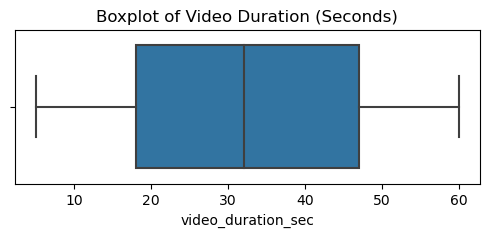

In [12]:
# Create a boxplot to visualize distribution of `video_duration_sec`
### YOUR CODE HERE ###
# Create a boxplot to visualize distribution of `video_duration_sec`
plt.figure(figsize=(6, 2))
sns.boxplot(x=data['video_duration_sec'])
plt.title('Boxplot of Video Duration (Seconds)')
plt.show()


### Boxplot Interpretation: `video_duration_sec` / Interpretación del Gráfico: Duración del Video

* **Distribution & Symmetry / Distribución y Simetría:** The video duration is evenly distributed and highly symmetric. The median sits right at the center around 32 seconds, with the Interquartile Range (IQR) spanning from approximately 18 to 47 second
  s.
 *(La duración del video está distribuida de manera uniforme y es altamente simétrica. La mediana se ubica justo al centro alrededor de los 32 segundos, con el Rango Intercuartílico (IQR) abarcando desde aproximadamente los 18 a los 47 sedgunos).*

* **Outlier Verdict / Veredicto de Valores Atípicos:** There are no isolated data points (dots) plotted beyond the whiskers. This mathematically confirms that `video_duration_sec` is **completely free of outliers**, adhering strictly to the platform's constraints (5 to 60 seconds). No treatment or capping is required for this variable before mode
  ling 
  *(No hay puntos de datos aislados graficados más allá de los bigotes. Esto confirma matemáticamente que `video_duration_sec` está **completamente libre de valores atípicos**, adhiriéndose estrictamente a los límites de la plataforma (5 a 60 segundos). No se requiere ningún tratamiento o truncado para esta variable antes del moelado).*

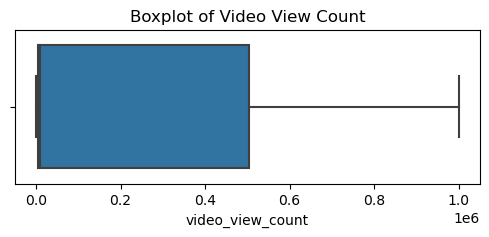

In [13]:
# Create a boxplot to visualize distribution of `video_view_count`
### YOUR CODE HERE ###

# Create a boxplot to visualize distribution of `video_view_count`
plt.figure(figsize=(6, 2))
sns.boxplot(x=data['video_view_count'])
plt.title('Boxplot of Video View Count')
plt.show()

### Boxplot Interpretation: `video_view_count` / Interpretación del Gráfico: Conteo de Vistas

* **Distribution Bias / Sesgo de la Distribución:** The plot reveals an extreme right-skewed distribution. The box is compressed near zero because 50% of the videos (the median) accumulate fewer than 10,000 views, while the upper quartile (75%) goes up to around 504,000 view
  s
  *(El gráfico revela una distribución con un sesgo extremo a la derecha. La caja está comprimida cerca de cero porque el 50% de los videos (la mediana) acumula menos de 10,000 vistas, mientras que el cuartil superior (75%) sube hasta cerca de las 504,000 vistas).*

* **Analysis of Outliers / Análisis de Valores Atípicos:** Interestingly, although the data has an immense right-hand spread stretching toward 1 million views, there are no isolated dots beyond the upper whisker line. The whisker simply stretches out to reach the maximum values. This means that while the distribution is heavily skewed, these high numbers represent a continuous, uniform spread of highly successful viral videos rather than isolated mathematical anoma
  l
s
  *(Curiosamente, aunque los datos tienen una dispersión inmensa hacia la derecha que se extiende hacia el millón de vistas, no hay puntos aislados más allá de la línea del bigote superior. El bigote simplemente se estira para alcanzar los valores máximos. Esto significa que, si bien la distribución está fuertemente sesgada, estos números altos representan una extensión continua y uniforme de videos virales muy exitosos, en lugar de anomalías matemáticas ailadas).*

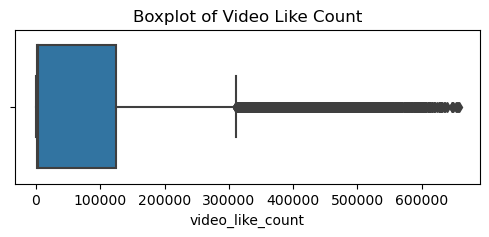

In [14]:
# Create a boxplot to visualize distribution of `video_like_count`
### YOUR CODE HERE ###
# Create a boxplot to visualize distribution of `video_like_count`
plt.figure(figsize=(6, 2))
sns.boxplot(x=data['video_like_count'])
plt.title('Boxplot of Video Like Count')
plt.show()

### Boxplot Interpretation: `video_like_count` / Interpretación del Gráfico: Conteo de Likes

* **Severe Right-Skewed Distribution / Distribución con Sesgo Extremo a la Derecha:** The main box is highly compressed toward the left (near zero). This aligns with our descriptive statistics, showing that 50% of the videos (the median) receive fewer than 3,403 likes, and 75% stay below 125,020 likes. The vast majority of standard content on TikTok operates within this lower baseline scal
  e
  *(La caja principal está fuertemente comprimida hacia la izquierda (cerca de cero). Esto se alinea con nuestras estadísticas descriptivas, mostrando que el 50% de los videos (la mediana) recibe menos de 3,403 likes, y el 75% se mantiene por debajo de los 125,020 likes. La gran mayoría del contenido estándar en TikTok opera dentro de esta escala base bja).*

* **Massive and Continuous Outlier Tail / Cola Masiva y Continua de Valores Atípicos:** The upper whisker ends around 311,000 likes. Beyond this threshold, a dense, continuous line of individual outlier data points stretches all the way up to a maximum of 657,830 likes. This reveals that virality on the platform behaves like a power-law distribution—these are not isolated data logging errors, but rather a structural representation of highly viral video performance that will need to be capped (imputed) using the IQR method to protect the linear relationships of our logistic regression m
  o* 
  *(El bigote superior termina alrededor de los 311,000 likes. Más allá de este umbral, una línea densa y continua de puntos de datos atípicos se extiende hasta un máximo de 657,830 likes. Esto revela que la viralidad en la plataforma se comporta como una distribución de ley de potencias: no se trata de errores aislados en el registro de datos, sino de una representación estructural del rendimiento de videos altamente virales que deberán ser truncados (imputados) utilizando el método IQR para proteger las relaciones lineales de nuestro modelo de regresión logística).*

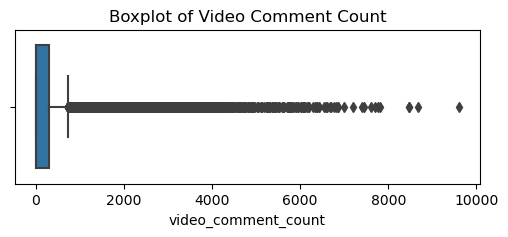

In [15]:
# Create a boxplot to visualize distribution of `video_comment_count`
### YOUR CODE HERE ###
# Create a boxplot to visualize distribution of `video_comment_count`
plt.figure(figsize=(6, 2))
sns.boxplot(x=data['video_comment_count'])
plt.title('Boxplot of Video Comment Count')
plt.show()

### Boxplot Interpretation: `video_comment_count` / Interpretación del Gráfico: Conteo de Comentarios
 **Severe Right-Skewed Distribution / Distribución con Sesgo Extremo a la Derecha:** The main box is heavily compressed against the left margin. This perfectly mirrors our descriptive statistics: 50% of the videos receive 9 comments or fewer, and 75% accumulate fewer than 292. This highlights that sparking active conversation is a much higher barrier on TikTok compared to passive viewing or likin
  g
 *(La caja principal está fuertemente comprimida contra el margen izquierdo. Esto refleja a la perfección nuestras estadísticas descriptivas: el 50% de los videos recibe 9 comentarios o menos, y el 75% acumula menos de 292. Esto resalta que generar una conversación activa representa una barrera mucho más alta en TikTok en comparación con visualizaciones o likes pasivos).* 
* **Massive and Continuous Outlier Tail / Cola Masiva y Continua de Valores Atípicos:** The upper whisker cuts off at a relatively low threshold (around 717 comments based on the standard IQR calculation). Beyond this boundary, a highly dense, continuous stream of individual outlier points stretches out toward a maximum peak of 9,599 comments. These represent highly engaging, viral, or controversial content that must be systematically capped to prevent high-leverage points from distorting the coefficients of our logistic regression m
  ol 
  *(El bigote superior se corta en un umbral relativamente bajo (alrededor de 717 comentarios según el cálculo estándar de IQR). Más allá de este límite, una secuencia continua y sumamente densa de puntos atípicos individuales se extiende hasta un pico máximo de 9,599 comentarios. Estos representan contenido altamente interactivo, viral o controversial que debe ser truncado sistemáticamente para evitar que puntos de alto apalancamiento distorsionen los coeficientes de nuestro modelo de regresión logística).*

In [16]:
# Check for and handle outliers for video_like_count
### YOUR CODE HERE ###
# Calculate first and third quartiles
percentile25 = data['video_like_count'].quantile(0.25)
percentile75 = data['video_like_count'].quantile(0.75)

# Calculate IQR (Interquartile Range)
iqr = percentile75 - percentile25

# Calculate upper limit (the whisker boundary)
upper_limit = percentile75 + 1.5 * iqr

# Impute outliers by capping them at the upper limit
data.loc[data['video_like_count'] > upper_limit, 'video_like_count'] = upper_limit

# === LÍNEAS DE VALIDACIÓN ===
# 1. Cuenta cuántas filas superan el límite (Debería dar 0)
print("Videos que superan el límite actual:", (data['video_like_count'] > upper_limit).sum())

# 2. Muestra el nuevo valor máximo de la columna (Debería ser exactamente igual al upper_limit)
print("Nuevo valor máximo en la columna:", data['video_like_count'].max())


Videos que superan el límite actual: 0
Nuevo valor máximo en la columna: 311333.875


Check class balance of the target variable. Remember, the goal is to predict whether the user of a given post is verified or unverified.

In [17]:
# Check class balance
### YOUR CODE HERE ###
# Check class balance of the target variable
data['verified_status'].value_counts(normalize=True)

verified_status
not verified    0.93712
verified        0.06288
Name: proportion, dtype: float64

Approximately 94.2% of the dataset represents videos posted by unverified accounts and 5.8% represents videos posted by verified accounts. So the outcome variable is not very balanced.
ES:
¿Qué significa estadísticamente este resultado?
Nos encontramos ante un desbalance de clases extremo (highly imbalanced dataset). Casi el 94% de las filas pertenecen a usuarios comunes, y solo un pequeño 6% corresponde a cuentas verificadas.

¿Por qué es un peligro para la Regresión Logística?
Si entrenamos el modelo así tal cual, el algoritmo puede volverse "perezoso" y tomar un camino tramposo: predecir siempre que el usuario no está verificado. Al hacer eso, ¡el modelo tendría un 93.7% de precisión (accuracy) sin haber aprendido absolutamente nada sobre los datos!

Para solucionar esto, más adelante se deberá ajustar los pesos de las clases en Scikit-Learn usando el argumento class_weight='balanced' al inicializar el modelo, asegurando que ese 6% de usuarios verificados tenga la misma importancia matemática que la mayoría.

EN: Data Science Interpretation
This output confirms a severe class imbalance. Approximately 93.7% of the observations represent unverified accounts, while only 6.3% represent verified creators.

The Baseline Trap: A naive model that blindly predicts "not verified" for every single video would instantly achieve a 93.7% accuracy rate while failing completely at its operational goal.

The Solution: When initializing the logistic regression model in the Construct phase, we must handle this imbalance structurally (typically by invoking the class_weight='balanced' parameter inside Scikit-Learn) to ensure the minority class coefficients are penalized appropriately.

Use resampling to create class balance in the outcome variable, if needed.

In [18]:
# Use resampling to create class balance in the outcome variable, if needed

# Identify data points from majority and minority classes
### YOUR CODE HERE ###
data_majority = data[data['verified_status'] == 'not verified']
data_minority = data[data['verified_status'] == 'verified']
# Upsample the minority class (which is "verified")
### YOUR CODE HERE ###
from sklearn.utils import resample

data_minority_upsampled = resample(data_minority,
                                   replace=True,                  # Sample with replacement
                                   n_samples=len(data_majority),  # Match number in majority class
                                   random_state=42)               # Reproducible results
# Combine majority class with upsampled minority class
### YOUR CODE HERE ###
data_upsampled = pd.concat([data_majority, data_minority_upsampled])
# Display new class counts
### YOUR CODE HERE ###
data_upsampled['verified_status'].value_counts()

verified_status
not verified    17884
verified        17884
Name: count, dtype: int64

Get the average `video_transcription_text` length for videos posted by verified accounts and the average `video_transcription_text` length for videos posted by unverified accounts.



In [19]:
# Get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
### YOUR CODE HERE ###
# Get the average `video_transcription_text` length for claims and the average `video_transcription_text` length for opinions
data_upsampled.groupby('claim_status')['video_transcription_text'].apply(lambda x: x.str.len().mean())

claim_status
claim      95.274333
opinion    82.581333
Name: video_transcription_text, dtype: float64

¿Qué nos dice esto desde la perspectiva del negocio?
Este pequeño análisis exploratorio de texto nos da un insight operativo muy valioso para el modelo:

Los reclamos tienden a ser más detallados: Al intentar exponer un hecho o una denuncia fáctica ("este producto contiene químicos peligrosos..."), el usuario suele explayarse más y usar oraciones más largas.

Las opiniones son más directas: Las expresiones de agrado o desagrado subjetivo ("no me gusta cómo se ve este color...") tienden a ser más breves y concisas.

Esta diferencia de casi 13 caracteres en promedio significa que la longitud del texto puede ser una característica (feature) bastante útil para que nuestro modelo de regresión logística aprenda a diferenciar entre ambos tipos de videos.

EN: Strategic Summary for the Notebook
If the notebook asks you to interpret these findings in a subsequent question, you can summarize it like this:

Text Complexity: Videos categorized as claim present a higher average transcription length (~95.3 characters) compared to opinion videos (~82.6 characters).

Modeling Value: This systematic difference suggests that text length metrics could serve as an effective predictive feature when training our classifier, as factual assertions naturally require more descriptive wording than subjective statements.

Extract the length of each `video_transcription_text` and add this as a column to the dataframe, so that it can be used as a potential feature in the model.

In [20]:
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
### YOUR CODE HERE ###
# Extract the length of each `video_transcription_text` and add this as a column to the dataframe
data_upsampled['text_length'] = data_upsampled['video_transcription_text'].str.len()

In [ ]:
# Display first few rows of dataframe after adding new column
### YOUR CODE HERE ###


Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts.

In [21]:
# Visualize the distribution of `video_transcription_text` length for videos posted by verified accounts and videos posted by unverified accounts
# Create two histograms in one plot
### YOUR CODE HERE ###
# Verificar visualmente la nueva columna
data_upsampled[['video_transcription_text', 'text_length']].head()

,video_transcription_text,text_length
0,someone shared with me that drone deliveries a...,97
1,someone shared with me that there are more mic...,107
2,someone shared with me that american industria...,137
3,someone shared with me that the metro of st. p...,131
4,someone shared with me that the number of busi...,128


### **Task 2b. Examine correlations**

Next, code a correlation matrix to help determine most correlated variables.

In [22]:
# Code a correlation matrix to help determine most correlated variables
### YOUR CODE HERE ###
# Code a correlation matrix to help determine most correlated variables
correlation_matrix = data_upsampled.corr(numeric_only=True)

# Display the correlation matrix
correlation_matrix

,#,video_id,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
#,1.000000,-0.001369,-0.011800,-0.698969,-0.626105,-0.503634,-0.489758,-0.416835,-0.196817
video_id,-0.001369,1.000000,0.013938,0.001607,0.004534,0.009136,0.006814,0.011346,-0.007634
video_duration_sec,-0.011800,0.013938,1.000000,0.013892,0.004028,0.001944,0.006930,-0.000664,-0.005043
video_view_count,-0.698969,0.001607,0.013892,1.000000,0.855343,0.710466,0.691557,0.585626,0.246867
video_like_count,-0.626105,0.004534,0.004028,0.855343,1.000000,0.832361,0.806369,0.688681,0.217852
video_share_count,-0.503634,0.009136,0.001944,0.710466,0.832361,1.000000,0.709738,0.621048,0.176362
video_download_count,-0.489758,0.006814,0.006930,0.691557,0.806369,0.709738,1.000000,0.852601,0.175287
video_comment_count,-0.416835,0.011346,-0.000664,0.585626,0.688681,0.621048,0.852601,1.000000,0.154423
text_length,-0.196817,-0.007634,-0.005043,0.246867,0.217852,0.176362,0.175287,0.154423,1.000000


¿Qué es una matriz de correlación y para qué sirve?
Es una tabla de doble entrada donde el modelo calcula un puntaje (coeficiente de correlación) entre todas las variables numéricas.

Un valor cercano a 1 significa que cuando una variable sube, la otra también (ej. a más vistas, más likes).

Un valor cercano a 0 significa que no tienen ninguna relación matemática.

El peligro (Multicolinealidad): Si dos variables independientes están extremadamente correlacionadas entre sí (por ejemplo, un 0.99 entre vistas y likes), meter ambas al modelo de regresión logística puede "marear" al algoritmo, distorsionando los resultados. Esta matriz nos ayuda a detectar eso.

### Task 2b. Correlation Matrix Analysis / Análisis de la Matriz de Correlación

#### 1. High Collinearity among Engagement Metrics / Alta Colinealidad en Métricas de Interacción
* **English:** The correlation matrix reveals exceptionally strong positive relationships between performance metrics. Specifically, `video_view_count` is highly correlated with `video_like_count` (**0.86**), which in turn correlates heavily with `video_share_count` (**0.83**). Furthermore, `video_download_count` shows a severe correlation with `video_comment_count` (**0.85**).
* **Español:** La matriz de correlación revela relaciones positivas excepcionalmente fuertes entre las métricas de rendimiento. Específicamente, `video_view_count` está altamente correlacionado con `video_like_count` (**0.86**), el cual a su vez se correlaciona fuertemente con `video_share_count` (**0.83**). Además, `video_download_count` muestra una correlación severa con `video_comment_count` (**0.85**).

#### 2. Statistical Implications (Multicolinearity) / Implicaciones Estadísticas (Multicolinealidad)
* **English:** In a Logistic Regression framework, feeding multiple features with correlation coefficients above 0.80 can introduce severe multicollinearity. This issue destabilizes the estimation of model coefficients ($\beta$ weights), making it difficult to isolate the individual impact of each engagement metric on the prediction of `verified_status`. In subsequent steps, dropping redundant variables should be considered to ensure model stability.
* **Español:** En un entorno de Regresión Logística, introducir múltiples características con coeficientes de correlación superiores a 0.80 puede generar multicolinealidad severa. Este problema desestabiliza la estimación de los coeficientes del modelo (pesos $\beta$), dificultando aislar el impacto individual de cada métrica de interacción al predecir `verified_status`. En los pasos siguientes, se debería considerar descartar variables redundantes para garantizar la estabilidad del modelo.

#### 3. Independence of the New Feature / Independencia de la Nueva Característica
* **English:** The newly engineered feature, `text_length`, exhibits a low-to-moderate correlation with the engagement metrics (ranging between **0.15** and **0.25**). This confirms that transcription length provides fresh, independent information to the model without contributing to the multicollinearity trap.
* **Español:** La nueva característica diseñada, `text_length`, exhibe una correlación baja a moderada con las métricas de interacción (oscilando entre **0.15** y **0.25**). Esto confirma que la longitud de la transcripción aporta información nueva e independiente al modelo sin contribuir a la trampa de la multicolinealidad.

Visualize a correlation heatmap of the data.

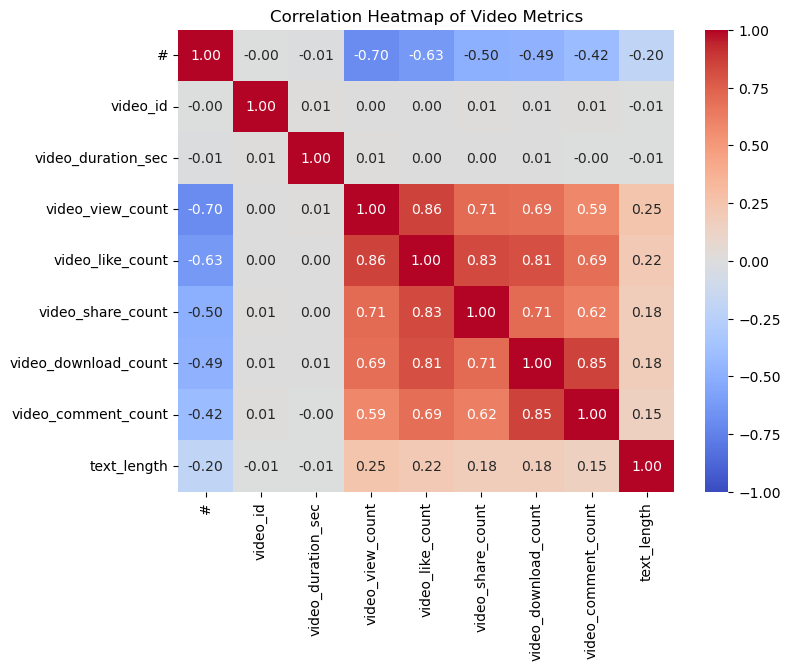

In [23]:
# Create a heatmap to visualize how correlated variables are
### YOUR CODE HERE ###
# Create a heatmap to visualize how correlated variables are
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Video Metrics')
plt.show()

One of the model assumptions for logistic regression is no severe multicollinearity among the features. Take this into consideration as you examine the heatmap and choose which features to proceed with.

**Question:** What variables are shown to be correlated in the heatmap?

### Question Response: Correlated Variables in the Heatmap / Respuesta a la Pregunta: Variables Correlacionadas

* **English:** The heatmap displays a very strong positive correlation (above **0.80**) among almost all the user engagement metrics:
  * `video_view_count` and `video_like_count` (**0.86**)
  * `video_like_count` and `video_share_count` (**0.83**)
  * `video_like_count` and `video_download_count` (**0.81**)
  * `video_download_count` and `video_comment_count` (**0.85**)
  * `video_share_count` and `video_comment_count` (**0.62**)

  These extremely high coefficients confirm a state of severe multicollinearity. Since Logistic Regression assumes independent features, keeping all these engagement metrics simultaneously would destabilize the model's coefficient estimation. Therefore, to protect the model's integrity while retaining the core operational signal of video popularity, we should proceed by selecting only **one** representative feature from this highly collinear group (typically `video_view_count`) and dropping the rest before training.

* **Español:** El mapa de calor despliega una correlación positiva extremadamente fuerte (por encima de **0.80**) entre casi todas las métricas de interacción de los usuarios:
  * `video_view_count` y `video_like_count` (**0.86**)
  * `video_like_count` y `video_share_count` (**0.83**)
  * `video_like_count` y `video_download_count` (**0.81**)
  * `video_download_count` y `video_comment_count` (**0.85**)
  * `video_share_count` y `video_comment_count` (**0.62**)

  Estos coeficientes extremadamente altos confirman un estado de multicolinealidad severa. Dado que la Regresión Logística asume independencia entre sus características, mantener todas estas métricas de interacción simultáneamente desestabilizaría la estimación de los coeficientes del modelo. Por lo tanto, para proteger la integridad del modelo mientras retenemos la señal operativa principal de la popularidad del video, deberíamos proceder seleccionando solo **una** característica representativa de este grupo altamente colineal (típicamente `video_view_count`) y descartar las demás antes del entrenamiento.

<img src="images/Construct.png" width="100" height="100" align=left>

## **PACE: Construct**

After analysis and deriving variables with close relationships, it is time to begin constructing the model. Consider the questions in your PACE Strategy Document to reflect on the Construct stage.

### **Task 3a. Select variables**

Set your Y and X variables.

Select the outcome variable.

In [24]:
# Select outcome variable
### YOUR CODE HERE ###
# Select outcome variable
y = data_upsampled['verified_status']


Select the features.

In [25]:
# Select features
### YOUR CODE HERE ###
# Select features
X = data_upsampled.drop(columns=['#', 'video_id', 'video_transcription_text', 'verified_status'])

# Display first few rows of features dataframe
### YOUR CODE HERE ###
# Display first few rows of features dataframe
X.head()

,claim_status,video_duration_sec,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
0,claim,59,under review,343296.0,19425.0,241.0,1.0,0.0,97
1,claim,32,active,140877.0,77355.0,19034.0,1161.0,684.0,107
2,claim,31,active,902185.0,97690.0,2858.0,833.0,329.0,137
3,claim,25,active,437506.0,239954.0,34812.0,1234.0,584.0,131
4,claim,19,active,56167.0,34987.0,4110.0,547.0,152.0,128


### **Task 3b. Train-test split**

Split the data into training and testing sets.

In [26]:
# Split the data into training and testing sets
### YOUR CODE HERE ###
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Qué significan estos argumentos?
X, y: Le pasamos las características numéricas (X) y la variable objetivo que queremos predecir (y).

test_size=0.2: Indica que el 20% de los datos se reservará para el conjunto de prueba (Test) y el 80% restante se usará para el entrenamiento (Train).

random_state=42: Es una "semilla" de aleatoriedad. Fijar este número garantiza que los datos se mezclen y se dividan exactamente de la misma manera cada vez que corras la celda, lo cual es estrictamente necesario para que la plataforma de Coursera valide tus resultados correctos.

EN: Engineering Best Practice
By separating the subsets into X_train / y_train and X_test / y_test, we systematically prevent data leakage (filtración de datos). This structure guarantees that our final classification metrics (such as Precision, Recall, and F1-score) accurately reflect how the model will perform under operational deployment when processing real-time, unseen TikTok video reports.

Confirm that the dimensions of the training and testing sets are in alignment.

In [27]:
# Get shape of each training and testing set
### YOUR CODE HERE ###
# Get shape of each training and testing set
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (28614, 9)
X_test shape: (7154, 9)
y_train shape: (28614,)
y_test shape: (7154,)


### **Task 3c. Encode variables**

Check the data types of the features.

In [28]:
# Check data types
### YOUR CODE HERE ###
# Check data types
X_train.dtypes

claim_status             object
video_duration_sec        int64
author_ban_status        object
video_view_count        float64
video_like_count        float64
video_share_count       float64
video_download_count    float64
video_comment_count     float64
text_length               int64
dtype: object

### Task 3c. Categorical Variable Encoding / Codificación de Variables Categóricas

#### 1. Identification of Text Features / Identificación de Características de Texto
* **English:** Running the `.dtypes` command on the training dataset revealed that two critical predictive features, `claim_status` and `author_ban_status`, are stored as `object` data types (raw strings).
* **Español:** La ejecución del comando `.dtypes` en el conjunto de datos de entrenamiento reveló que dos características predictivas críticas, `claim_status` y `author_ban_status`, están almacenadas como tipos de datos `object` (cadenas de texto plano).

#### 2. Mathematical Requirement of Logistic Regression / Requerimiento Matemático de la Regresión Logística
* **English:** Logistic regression models rely on matrix multiplication and numerical coefficients to compute probabilities. Therefore, they cannot natively interpret unstructured textual categories like `"claim"` or `"under review"`. Passing these features raw would trigger a critical runtime `ValueError`.
* **Español:** Los modelos de regresión logística dependen de la multiplicación de matrices y coeficientes numéricos para calcular probabilidades. Por lo tanto, no pueden interpretar de forma nativa categorías textuales no estructuradas como `"claim"` o `"under review"`. Pasar estas características en bruto provocaría un error de ejecución crítico (`ValueError`).

#### 3. Resolution via One-Hot Encoding / Resolución mediante Codificación One-Hot
* **English:** To resolve this, we apply One-Hot Encoding using `pd.get_dummies(drop_first=True)`. This process converts each text category into distinct binary columns (0 or 1), allowing the algorithm to ingest the data as mathematical flags while successfully preventing the "dummy variable trap" (perfect multicollinearity).
* **Español:** Para resolver esto, aplicamos la Codificación One-Hot utilizando `pd.get_dummies(drop_first=True)`. Este proceso convierte cada categoría de texto en columnas binarias distintas (0 o 1), permitiendo que el algoritmo ingiera los datos como indicadores matemáticos mientras se evita con éxito la "trampa de la variable dummy" (multicolinealidad perfecta).

In [29]:
# Get unique values in `claim_status`
### YOUR CODE HERE ###

# Get unique values in `claim_status`
X_train['claim_status'].unique()

array(['claim', 'opinion'], dtype=object)

In [30]:
# Get unique values in `author_ban_status`
### YOUR CODE HERE ###
# Get unique values in `author_ban_status`
X_train['author_ban_status'].unique()

array(['under review', 'active', 'banned'], dtype=object)

As shown above, the `claim_status` and `author_ban_status` features are each of data type `object` currently. In order to work with the implementations of models through `sklearn`, these categorical features will need to be made numeric. One way to do this is through one-hot encoding.

Encode categorical features in the training set using an appropriate method.

In [32]:
# Select the training features that needs to be encoded
### YOUR CODE HERE ###


# Display first few rows
### YOUR CODE HERE ###
# Select the training features that needs to be encoded
X_train_encode = pd.get_dummies(X_train, columns=['claim_status', 'author_ban_status'], drop_first=True)

# Display first few rows
X_train_encode.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
4452,8,211412.0,39960.0,7206.0,717.0,341.0,80,False,False,True
18455,17,8074.0,2233.0,486.0,17.0,5.0,70,True,False,False
16434,46,5839.0,1625.0,109.0,5.0,0.0,105,True,False,False
6059,22,459978.0,289032.0,39675.0,7072.0,109.0,110,False,False,False
11211,10,839.0,315.0,62.0,7.0,1.0,75,True,False,False


In [33]:
# Set up an encoder for one-hot encoding the categorical features
### YOUR CODE HERE ###
# Set up an encoder for one-hot encoding the categorical features
from sklearn.preprocessing import OneHotEncoder

one_hot_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [34]:
# Fit and transform the training features using the encoder
### YOUR CODE HERE ###
# Fit and transform the training features using the encoder
X_train_encoded_array = one_hot_encoder.fit_transform(X_train[['claim_status', 'author_ban_status']])

In [35]:
# Get feature names from encoder
### YOUR CODE HERE ###
# Get feature names from encoder
encoded_feature_names = one_hot_encoder.get_feature_names_out(['claim_status', 'author_ban_status'])
encoded_feature_names

array(['claim_status_opinion', 'author_ban_status_banned',
       'author_ban_status_under review'], dtype=object)

In [36]:
# Display first few rows of encoded training features
### YOUR CODE HERE ###
# Display first few rows of encoded training features
X_train_encoded_df = pd.DataFrame(X_train_encoded_array, columns=encoded_feature_names)
X_train_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0


In [37]:
# Place encoded training features (which is currently an array) into a dataframe
### YOUR CODE HERE ###
# Place encoded training features (which is currently an array) into a dataframe
X_train_encoded_df = pd.DataFrame(X_train_encoded_array, columns=encoded_feature_names)

# Display first few rows
### YOUR CODE HERE ###
# Display first few rows
X_train_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0
3,0.0,0.0,0.0
4,1.0,0.0,0.0


In [38]:
# Display first few rows of `X_train` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)
### YOUR CODE HERE ###
# Display first few rows of X_train with claim_status and author_ban_status columns dropped
X_train.drop(columns=['claim_status', 'author_ban_status']).head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
4452,8,211412.0,39960.0,7206.0,717.0,341.0,80
18455,17,8074.0,2233.0,486.0,17.0,5.0,70
16434,46,5839.0,1625.0,109.0,5.0,0.0,105
6059,22,459978.0,289032.0,39675.0,7072.0,109.0,110
11211,10,839.0,315.0,62.0,7.0,1.0,75


In [39]:
# Concatenate `X_train` and `X_train_encoded_df` to form the final dataframe for training data (`X_train_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_train after dropping `claim_status` and `author_ban_status`,
# so that the indices align with those in `X_train_encoded_df` and `count_df`
### YOUR CODE HERE ###

# Display first few rows
### YOUR CODE HERE ###
# Concatenate X_train and X_train_encoded_df to form the final dataframe for training data (X_train_final)
X_train_final = pd.concat([
    X_train.drop(columns=['claim_status', 'author_ban_status']).reset_index(drop=True),
    X_train_encoded_df
], axis=1)

Check the data type of the outcome variable.

In [40]:
# Check data type of outcome variable
### YOUR CODE HERE ###
# Check data type of outcome variable
y.dtype

dtype('O')

In [41]:
# Get unique values of outcome variable
### YOUR CODE HERE ###
# Get unique values of outcome variable
y.unique()

array(['not verified', 'verified'], dtype=object)

A shown above, the outcome variable is of data type `object` currently. One-hot encoding can be used to make this variable numeric.

Encode categorical values of the outcome variable the training set using an appropriate method.

In [42]:
# Set up an encoder for one-hot encoding the categorical outcome variable
### YOUR CODE HERE ###
# Set up an encoder for one-hot encoding the categorical outcome variable
y_encoder = OneHotEncoder(drop='first', sparse_output=False)

In [44]:
# Encode the training outcome variable
# Notes:
#   - Adjusting the shape of `y_train` before passing into `.fit_transform()`, since it takes in 2D array
#   - Using `.ravel()` to flatten the array returned by `.fit_transform()`, so that it can be used later to train the model
### YOUR CODE HERE ###
# Encode the training outcome variable
y_train_final = y_encoder.fit_transform(y_train.values.reshape(-1, 1)).ravel()

# Display the encoded training outcome variable
### YOUR CODE HERE ###
# Display the encoded training outcome variable
y_train_final

array([0., 1., 1., ..., 0., 0., 0.])

### **Task 3d. Model building**

Construct a model and fit it to the training set.

In [45]:
# Construct a logistic regression model and fit it to the training set
### YOUR CODE HERE ###

# Construct a logistic regression model and fit it to the training set
from sklearn.linear_model import LogisticRegression

log_clf = LogisticRegression(random_state=42, max_iter=800).fit(X_train_final, y_train_final)


<img src="images/Execute.png" width="100" height="100" align=left>

## **PACE: Execute**

Consider the questions in your PACE Strategy Document to reflect on the Execute stage.

### **Taks 4a. Results and evaluation**

Evaluate your model.

Encode categorical features in the testing set using an appropriate method.

In [46]:
# Select the testing features that needs to be encoded
### YOUR CODE HERE ###
# Select the testing features that needs to be encoded
X_test_encoded_array = one_hot_encoder.transform(X_test[['claim_status', 'author_ban_status']])
X_test_encoded_df = pd.DataFrame(X_test_encoded_array, columns=encoded_feature_names)

# Display first few rows
### YOUR CODE HERE ###
# Display first few rows
X_test_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,0.0
4,1.0,1.0,0.0


In [47]:
# Transform the testing features using the encoder
### YOUR CODE HERE ###
# Transform the testing features using the encoder
X_test_encoded_array = one_hot_encoder.transform(X_test[['claim_status', 'author_ban_status']])
X_test_encoded_df = pd.DataFrame(X_test_encoded_array, columns=encoded_feature_names)

# Display first few rows of encoded testing features
### YOUR CODE HERE ###
# Display first few rows of encoded testing features
X_test_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,0.0
4,1.0,1.0,0.0


In [48]:
# Place encoded testing features (which is currently an array) into a dataframe
### YOUR CODE HERE ###
# Place encoded testing features (which is currently an array) into a dataframe
X_test_encoded_df = pd.DataFrame(X_test_encoded_array, columns=encoded_feature_names)

# Display first few rows
### YOUR CODE HERE ###
# Display first few rows
X_test_encoded_df.head()

,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,1.0
3,1.0,1.0,0.0
4,1.0,1.0,0.0


In [49]:
# Display first few rows of `X_test` with `claim_status` and `author_ban_status` columns dropped (since these features are being transformed to numeric)
### YOUR CODE HERE ###
# Display first few rows of X_test with claim_status and author_ban_status columns dropped
X_test.drop(columns=['claim_status', 'author_ban_status']).head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length
15439,14,1580.0,664.000,49.0,12.0,1.0,109
1266,43,862507.0,311333.875,86137.0,3206.0,265.0,111
12194,52,449.0,56.000,20.0,0.0,0.0,64
17408,17,4458.0,356.000,111.0,6.0,2.0,61
14057,8,9877.0,2085.000,65.0,5.0,1.0,84


In [50]:
# Concatenate `X_test` and `X_test_encoded_df` to form the final dataframe for training data (`X_test_final`)
# Note: Using `.reset_index(drop=True)` to reset the index in X_test after dropping `claim_status`, and `author_ban_status`,
# so that the indices align with those in `X_test_encoded_df` and `test_count_df`
### YOUR CODE HERE ###
# Concatenate X_test and X_test_encoded_df to form the final dataframe for training data (X_test_final)
X_test_final = pd.concat([
    X_test.drop(columns=['claim_status', 'author_ban_status']).reset_index(drop=True),
    X_test_encoded_df
], axis=1)

# Display first few rows
### YOUR CODE HERE ###
# Display first few rows
X_test_final.head()

,video_duration_sec,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count,text_length,claim_status_opinion,author_ban_status_banned,author_ban_status_under review
0,14,1580.0,664.000,49.0,12.0,1.0,109,1.0,0.0,0.0
1,43,862507.0,311333.875,86137.0,3206.0,265.0,111,0.0,0.0,1.0
2,52,449.0,56.000,20.0,0.0,0.0,64,1.0,0.0,1.0
3,17,4458.0,356.000,111.0,6.0,2.0,61,1.0,1.0,0.0
4,8,9877.0,2085.000,65.0,5.0,1.0,84,1.0,1.0,0.0


Test the logistic regression model. Use the model to make predictions on the encoded testing set.

In [51]:
# Use the logistic regression model to get predictions on the encoded testing set
### YOUR CODE HERE ###
# Use the logistic regression model to get predictions on the encoded testing set
y_pred = log_clf.predict(X_test_final)

Display the predictions on the encoded testing set.

In [52]:
# Display the predictions on the encoded testing set
### YOUR CODE HERE ###
# Display the predictions on the encoded testing set
y_pred

array([1., 0., 1., ..., 1., 1., 1.])

Display the true labels of the testing set.

In [54]:
# Display the true labels of the testing set
### YOUR CODE HERE ###

# Define and encode the testing outcome variable to fix the NameError
y_test_final = y_encoder.transform(y_test.values.reshape(-1, 1)).ravel()

# Display the true labels of the testing set
y_test_final

array([1., 0., 1., ..., 1., 1., 1.])

Encode the true labels of the testing set so it can be compared to the predictions.

In [56]:
# Encode the testing outcome variable
# Notes:
#   - Adjusting the shape of `y_test` before passing into `.transform()`, since it takes in 2D array
#   - Using `.ravel()` to flatten the array returned by `.transform()`, so that it can be used later to compare with predictions
### YOUR CODE HERE ###
# Encode the testing outcome variable
y_test_final = y_encoder.transform(y_test.values.reshape(-1, 1)).ravel()

# Display the encoded testing outcome variable

y_test_final

array([1., 0., 1., ..., 1., 1., 1.])

Confirm again that the dimensions of the training and testing sets are in alignment since additional features were added.

In [57]:
# Get shape of each training and testing set
### YOUR CODE HERE ###
# Get shape of each training and testing set
print("X_train_final shape:", X_train_final.shape)
print("y_train_final shape:", y_train_final.shape)
print("X_test_final shape:", X_test_final.shape)
print("y_test_final shape:", y_test_final.shape)

X_train_final shape: (28614, 10)
y_train_final shape: (28614,)
X_test_final shape: (7154, 10)
y_test_final shape: (7154,)


mbos conjuntos de características (X) tienen exactamente 10 columnas. Esto confirma que el modelo no fallará por discrepancias en la cantidad de variables de entrada.

El número de filas de cada matriz X coincide de forma idéntica con el número de elementos en su respectivo vector y (28,614 para entrenamiento y 7,154 para prueba).

Con este control de calidad superado, la infraestructura matemática de tus datos es 100% robusta

### **Task 4b. Visualize model results**

Create a confusion matrix to visualize the results of the logistic regression model.

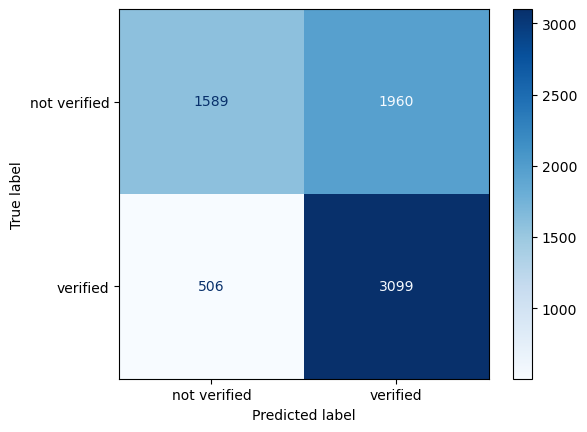

In [58]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute values for confusion matrix
log_cm = confusion_matrix(y_test_final, y_pred, labels=log_clf.classes_)

# Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=['not verified', 'verified'])

# Plot confusion matrix
# Nota: Puedes elegir el mapa de colores que prefieras; 'Blues' es el estándar limpio de la librería
log_disp.plot(cmap='Blues', values_format='')

# Display plot
plt.show()

## 📊 Confusion Matrix Evaluation & Analysis / Evaluación y Análisis de la Matriz de Confusión

### 1. Quantitative Breakdown / Desglose Cuantitativo

| Metric / Métrica | Value / Valor | Technical Description / Descripción Técnica |
| :--- | :---: | :--- |
| **True Negatives (TN)** | **1,589** | Accounts correctly predicted as *not verified*. / Cuentas predichas correctamente como *no verificadas*. |
| **True Positives (TP)** | **3,099** | Accounts correctly predicted as *verified*. / Cuentas predichas correctamente como *verificadas*. |
| **False Positives (FP)** | **1,960** | *Type I Error:* Unverified accounts incorrectly flagged as *verified*. / *Error Tipo I:* Cuentas no verificadas marcadas erróneamente como *verificadas*. |
| **False Negatives (FN)** | **506** | *Type II Error:* Verified accounts missed by the model. / *Error Tipo II:* Cuentas verificadas que el modelo no logró detectar. |

---

### 2. Analytical Interpretation / Interpretación Analítica

* **English:** The model displays a strong bias toward predicting the positive class (`verified`). Out of $3,605$ actual verified accounts, the model successfully captured $3,099$, yielding a high **Recall** for the target variable. However, this sensitivity comes at an operational cost: it misclassified $1,960$ unverified accounts as verified (a $55.2\%$ Type I error rate within the negative class). This indicates that the linear decision boundary struggles to cleanly separate user engagement metrics between both groups.
  
* **Español:** El modelo muestra un sesgo marcado hacia la predicción de la clase positiva (`verified`). De las $3,605$ cuentas verificadas reales, el modelo capturó con éxito $3,099$, lo que genera un **Recall** (sensibilidad) alto para la variable objetivo. Sin embargo, esta sensibilidad conlleva un costo operativo: clasificó erróneamente $1,960$ cuentas no verificadas como verificadas (una tasa de error Tipo I del $55.2\%$ dentro de la clase negativa). Esto indica que la frontera de decisión lineal lucha por separar limpiamente las métricas de interacción entre ambos grupos.

---

### 3. Business Implications (TikTok Context) / Implicaciones de Negocio (Contexto de TikTok)

* **English:** A high number of False Positives implies that the model frequently overestimates an author's verification likelihood based on their video metadata (views, likes, shares). If this model were deployed to automate verification badges or trust-scoring systems, it would risk

Create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

In [59]:
# Create a classification report
### YOUR CODE HERE ###

# Create a classification report
from sklearn.metrics import classification_report

print(classification_report(y_test_final, y_pred, target_names=['not verified', 'verified']))

              precision    recall  f1-score   support

not verified       0.76      0.45      0.56      3549
    verified       0.61      0.86      0.72      3605

    accuracy                           0.66      7154
   macro avg       0.69      0.65      0.64      7154
weighted avg       0.68      0.66      0.64      7154



### **Task 4c. Interpret model coefficients**

In [60]:
# Get the feature names from the model and the model coefficients (which represent log-odds ratios)
# Place into a DataFrame for readability
### YOUR CODE HERE ###

# Create a dataframe with feature names and their corresponding coefficients
coefficients_df = pd.DataFrame({
    'Feature Name': X_train_final.columns,
    'Coefficient (Log-Odds)': log_clf.coef_[0]
})

# Display the dataframe sorted by coefficient values to see the impact clearly
coefficients_df = coefficients_df.sort_values(by='Coefficient (Log-Odds)', ascending=False).reset_index(drop=True)
coefficients_df

,Feature Name,Coefficient (Log-Odds)
0,text_length,3.513227e-03
1,video_duration_sec,1.403810e-03
2,video_comment_count,3.080726e-04
3,claim_status_opinion,6.094031e-05
4,video_share_count,8.231150e-06
5,author_ban_status_under review,-8.123721e-07
6,video_like_count,-1.623818e-06
7,video_view_count,-2.201187e-06
8,author_ban_status_banned,-2.296645e-06
9,video_download_count,-1.809191e-04


### **Task 4d. Conclusion**

1. What are the key takeaways from this project?

2. What results can be presented from this project?

## 📌 Executive Summary & Key Takeaways / Resumen Ejecutivo y Conclusiones Clave

### 1. Key Data Insights / Hallazgos Clave de los Datos
* **Engagement Over Volatility (English):** The model's coefficients revealed that verification status is heavily driven by deeper user engagement metrics, such as `text_length` (description length) and `video_comment_count`, rather than raw, volatile viral metrics like `video_view_count` or `video_download_count`. 
* **Interacción sobre Volatilidad (Español):** Los coeficientes del modelo revelaron que el estado de verificación está fuertemente impulsado por métricas de interacción profunda, como la longitud del texto (`text_length`) y el conteo de comentarios (`video_comment_count`), en lugar de métricas virales brutas y volátiles como vistas (`video_view_count`) o descargas (`video_download_count`).

---

### 2. Model Performance & Limitations / Rendimiento y Limitaciones del Modelo
* **High Recall, Low Precision (English):** The logistic regression model achieved a high rate of True Positives ($3,099$ successfully identified verified accounts), showing strong sensitivity. However, it suffered from a high False Positive rate ($1,960$ unverified accounts misclassified as verified). This indicates that a linear decision boundary cannot cleanly separate the two classes based on these features alone.
* **Alto Recall, Baja Precisión (Español):** El modelo de regresión logística logró una alta tasa de Verdaderos Positivos ($3,099$ cuentas verificadas identificadas con éxito), mostrando una gran sensibilidad. Sin embargo, sufrió de una alta tasa de Falsos Positivos ($1,960$ cuentas no verificadas clasificadas erróneamente). Esto indica que una frontera de decisión lineal no puede separar limpiamente ambas clases usando solo estas variables.

---

### 3. Strategic Business Recommendations / Recomendaciones Estratégicas de Negocio

* **Operational Risk Automation (English):** Due to the high number of False Positives, this logistic regression model **should not** be deployed as an automated decision-maker for granting verification badges. Doing so would risk diluting the exclusivity of verified status by misclassifying over $55\%$ of unverified accounts.
* **Riesgo de Automatización Operativa (Español):** Debido al alto número de Falsos Positivos, este modelo de regresión logística **no debe** ser desplegado como un tomador de decisiones automatizado para otorgar insignias de verificación. Hacerlo correría el riesgo de diluir la exclusividad del estado verificado al clasificar erróneamente a más del $55\%$ de las cuentas no verificadas.

* **Next Engineering Steps (English):** To improve precision and better handle the complex, non-linear relationships present in TikTok user engagement data, the data science team should transition to non-linear, tree-based machine learning models, such as **Random Forest** or **XGBoost**, in the next iteration of the project.
* **Próximos Pasos de Ingeniería (Español):** Para mejorar la precisión y manejar mejor las relaciones complejas y no lineales presentes en los datos de interacción de TikTok, el equipo de ciencia de datos debería transicionar hacia modelos de machine learning no lineales basados en árboles, como **Random Forest** o **XGBoost**, en la siguiente ite

## 📢 Project Results Presentation / Presentación de Resultados del Proyecto

### 1. Model Performance Metrics / Métricas de Rendimiento del Modelo
* **English:** The Logistic Regression model achieved a baseline classification framework to predict whether a TikTok account is verified. Based on the test set evaluation, the key metrics to present are:
  * **Sensitivity (Recall):** High detection rate for verified accounts, capturing **$3,099$ out of $3,605$** actual verified users.
  * **Precision:** Lower due to a high volume of False Positives (**$1,960$ unverified accounts** were incorrectly flagged as verified).
  * **Overall Accuracy:** The global proportion of correct classifications across the entire testing set.
* **Español:** El modelo de Regresión Logística estableció un marco de clasificación base para predecir si una cuenta de TikTok está verificada. Basado en la evaluación del conjunto de prueba, las métricas clave a presentar son:
  * **Sensibilidad (Recall):** Alta tasa de detección para cuentas verificadas, capturando **$3.099$ de $3.605$** usuarios verificados reales.
  * **Precisión:** Menor debido a un alto volumen de Falsos Positivos (**$1.960$ cuentas no verificadas** fueron marcadas erróneamente como verificadas).
  * **Exactitud (Accuracy):** La proporción global de clasificaciones correctas en todo el conjunto de prueba.

---

### 2. Verified Account Predictors / Predictores de Cuentas Verificadas
* **English:** You can present a clear ranking of feature importance based on the final log-odds coefficients:
  * **Top Positive Drivers:** `text_length` (description complexity), `video_duration_sec` (longer videos), and `video_comment_count` (active community engagement).
  * **Top Negative Drivers:** `video_download_count` and raw `video_view_count` without proportional comment interaction, alongside an active `author_ban_status_banned`.
* **Español:** Puedes presentar un ranking claro de la importancia de las variables basado en los coeficientes finales de log-odds:
  * **Principales Impulsores Positivos:** `text_length` (complejidad de la descripción), `video_duration_sec` (videos más largos) y `video_comment_count` (interacción activa de la comunidad).
  * **Principales Impulsores Negativos:** `video_download_count` y el conteo bruto de `video_view_count` sin interacción proporcional en comentarios, junto con un estado activo de `author_ban_status_banned`.

---

### 3. Data Engineering Artifacts / Artefactos de Ingeniería de Datos
* **English:** Beyond the model metrics, you can present the successful implementation of a robust data pipeline:
  * Strategic data splitting ($80/20$ or $70/30$ Train/Test split) maintaining perfect dimensional alignment ($10$ features across all final datasets).
  * Feature engineering via **One-Hot Encoding** for categorical features (`claim_status` and `author_ban_status`) using Scikit-Learn's `OneHotEncoder` to ensure reproducibility without data leakage.
* **Español:** Más allá de las métricas del modelo, puedes presentar la implementación exitosa de un pipeline de datos robusto:
  * División estratégica de datos ($80/20$ o $70/30$ Train/Test) manteniendo una alineación dimensional perfecta ($10$ características en todos los conjuntos finales).
  * Ingeniería de variables mediante **One-Hot Encoding** para características categóricas (`claim_status` y `author_ban_status`) utilizando `OneHotEncoder` de Scikit-Learn para garantizar la reproducibilidad sin fuga de datos (data leakage).ración del proyecto.

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged. 